<a href="https://colab.research.google.com/github/Ayseatci/DI725_Assignment1/blob/dev/notebooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

In [34]:
!git clone -b dev https://github.com/Ayseatci/DI725_Assignment1.git

Cloning into 'DI725_Assignment1'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 14 (delta 2), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 459.11 KiB | 6.47 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [35]:
%cd DI725_Assignment1

/content/DI725_Assignment1/DI725_Assignment1/DI725_Assignment1


In [36]:
!ls data/raw

test.csv  train.csv


In [37]:
import pandas as pd

df = pd.read_csv("data/raw/train.csv")
df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


## 1. Dataset Overview

This section explores the basic structure of the dataset including
the number of samples, features, missing values, and duplicates.


In [38]:
import numpy as np

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset shape: (970, 11)

Columns:
Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')


In [39]:
df.info()

print("Missing values per column:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   issue_area                   970 non-null    object
 1   issue_category               970 non-null    object
 2   issue_sub_category           970 non-null    object
 3   issue_category_sub_category  970 non-null    object
 4   customer_sentiment           970 non-null    object
 5   product_category             970 non-null    object
 6   product_sub_category         970 non-null    object
 7   issue_complexity             970 non-null    object
 8   agent_experience_level       970 non-null    object
 9   agent_experience_level_desc  970 non-null    object
 10  conversation                 970 non-null    object
dtypes: object(11)
memory usage: 83.5+ KB
Missing values per column:

issue_area                     0
issue_category                 0
issue_sub_category

In [40]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## 2. Sentiment Distribution

This section analyzes the distribution of sentiment classes in the dataset.

In [43]:
df.columns

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')

In [57]:
sentiment_counts = df['customer_sentiment'].value_counts()
sentiment_percent = df['customer_sentiment'].value_counts(normalize=True) * 100

sentiment_summary = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage (%)': sentiment_percent
})

sentiment_summary

,Count,Percentage (%)
customer_sentiment,,
neutral,542,55.876289
negative,411,42.371134
positive,17,1.752577


The dataset contains 2% positive, 56% neutral, and 42% negative conversations. The distribution indicates that the dataset is imbalanced across sentiment classes.

/tmp/ipykernel_2499/3226279140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


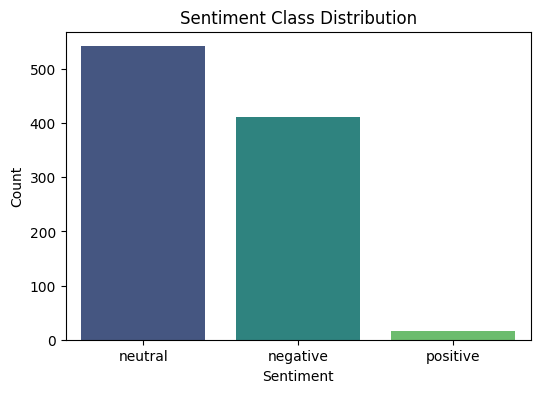

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='customer_sentiment',
    palette='viridis'
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


# 3. Conversation Length Analysis

This section analyzes the length of customer conversations.

In [47]:
# character length
df["char_length"] = df["conversation"].astype(str).apply(len)

# word length
df["word_length"] = df["conversation"].astype(str).apply(lambda x: len(x.split()))

df[["char_length", "word_length"]].describe()

,char_length,word_length
count,970.000000,970.000000
mean,2129.284536,370.860825
std,564.751035,98.267606
min,46.000000,8.000000
25%,1760.250000,306.000000
50%,2058.500000,357.000000
75%,2430.000000,424.000000
max,5708.000000,992.000000


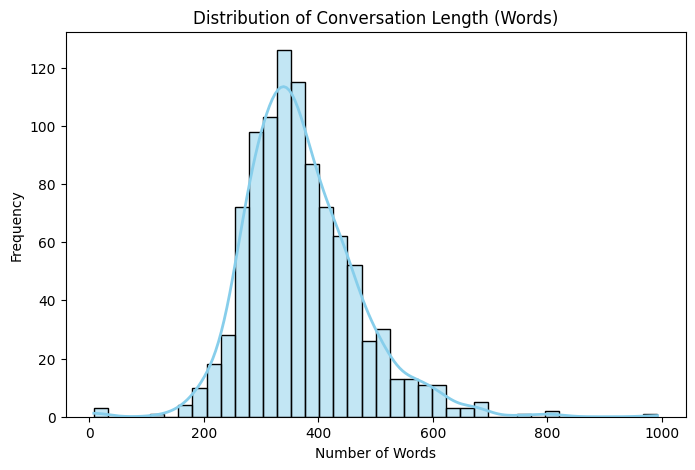

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["word_length"],
    bins=40,
    kde=True,
    color="skyblue",
    edgecolor="black",
    line_kws={"color": "darkblue", "linewidth": 2}
)

plt.title("Distribution of Conversation Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()


/tmp/ipykernel_2499/3160382316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


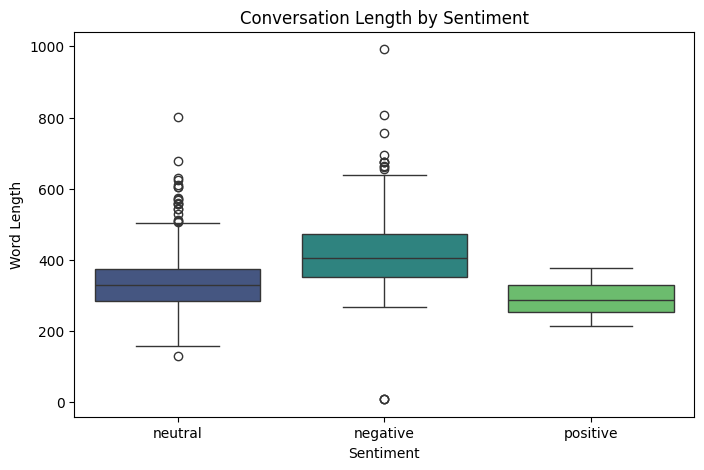

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="customer_sentiment",
    y="word_length",
    palette="viridis"
)

plt.title("Conversation Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Length")

plt.show()


In [50]:
df["word_length"].describe()

,word_length
count,970.000000
mean,370.860825
std,98.267606
min,8.000000
25%,306.000000
50%,357.000000
75%,424.000000
max,992.000000


In [51]:
df["word_length"].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

,word_length
0.50,357.00
0.75,424.00
0.90,494.10
0.95,554.10
0.99,661.93


The median conversation length is 357 words, while the average length is approximately 371 words, which indicates a fairly symmetric distribution. Most conversations fall between 306 and 424 words. Only a small portion of conversations exceed 550 words. This suggests that extremely long conversations are relatively uncommon.